In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

In [13]:
df = pd.read_csv('./data/cytof.csv', index_col=0)
df['observableId'].unique()

array(['CyclinB', 'GAPDH', 'IdU', 'Ki.67', 'b.CATENIN', 'cleavedCas',
       'p.4EBP1', 'p.AKT.Thr308.', 'p.AMPK', 'p.Akt.Ser473.', 'p.BTK',
       'p.CREB', 'p.ERK', 'p.FAK', 'p.GSK3b', 'p.H3', 'p.HER2', 'p.JNK',
       'p.MAP2K3', 'p.MAPKAPK2', 'p.MEK', 'p.MKK3.MKK6', 'p.MKK4',
       'p.NFkB', 'p.PDPK1', 'p.PLCg2', 'p.RB', 'p.S6', 'p.S6K',
       'p.SMAD23', 'p.SRC', 'p.STAT1', 'p.STAT3', 'p.STAT5', 'p.p38',
       'p.p53', 'p.p90RSK'], dtype=object)

In [14]:
def nan_euclidean(u, v):
    mask = np.isfinite(u) & np.isfinite(v)
    if np.sum(mask) == 0:
        return np.nan  # Or a large constant like 1e6
    return np.mean(np.square(u[mask] - v[mask]))

In [15]:
def plot_markers(cytof_markers, pmarkers):
    df = pd.read_csv('./data/cytof.csv', index_col=0)
    df = df[df['observableId'].isin(cytof_markers)]
    cell_lines = df['preequilibrationConditionId'].unique()
    df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
    dfp = df.pivot_table(index=['treatment', 'time', 'observableId'], columns='preequilibrationConditionId', values='measurement').reset_index()

    # hierarchical clustering
    distance_matrix = pdist(dfp.loc[
        (dfp.treatment=='EGF') & (dfp.isna().sum(axis=1) < 10),
        cell_lines
    ].T, metric=nan_euclidean)
    linkage_matrix = linkage(distance_matrix, method='centroid')
    d = dendrogram(linkage_matrix, labels=cell_lines, no_plot=True)
    n_treatments = dfp['treatment'].nunique()
    n_observables = dfp['observableId'].nunique()
    fig, axes = plt.subplots(figsize=(40, 15), nrows=n_observables+2, ncols=n_treatments)

    df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

    df_tx = df_tx[df_tx['observableId'].isin(pmarkers)].pivot_table(
        index='observableId',
        columns='preequilibrationConditionId',
        values='measurement'
    )

    df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

    df_px = df_px[df_px['observableId'].isin(pmarkers)].pivot_table(
        index='observableId',
        columns='preequilibrationConditionId',
        values='measurement'
    )

    gb = ['observableId', 'treatment',]
    for iax, (ax, ((marker, treatment), group)) in enumerate(zip(axes.flatten(), dfp.groupby(gb))):
        df_plot = group[group.isna().sum(axis=1) < 30]  # remove rows with too many NaNs
        time = df_plot['time'].unique()
        df_plot = df_plot.drop(columns=gb+['time'])
        sns.heatmap(
            df_plot[d['ivl']], ax=ax, cmap='cubehelix', cbar=False, yticklabels=time,
        )
        ax.set_xticklabels([])
        if iax < n_treatments:
            ax.set_title(treatment)
        if iax % n_treatments == 0:
            ax.set_ylabel(marker)
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')
    for ax in axes[-2,:]:
        sns.heatmap(
            df_px[d['ivl']], ax=ax, cmap='viridis', cbar=False, yticklabels=True,
        )
        ax.set_xticklabels([])
        ax.set_ylabel('proteomics')
        ax.set_xlabel('')
    for ax in axes[-1,:]:
        sns.heatmap(
            df_tx[d['ivl']], ax=ax, cmap='viridis', cbar=False, yticklabels=True,
        )
        ax.set_xticks([x+0.7 for x in range(len(d['ivl']))])
        ax.set_xticklabels(d['ivl'], rotation=90)
        ax.set_xlabel('cell lines')
        ax.set_ylabel('transcriptomics')
    plt.tight_layout()

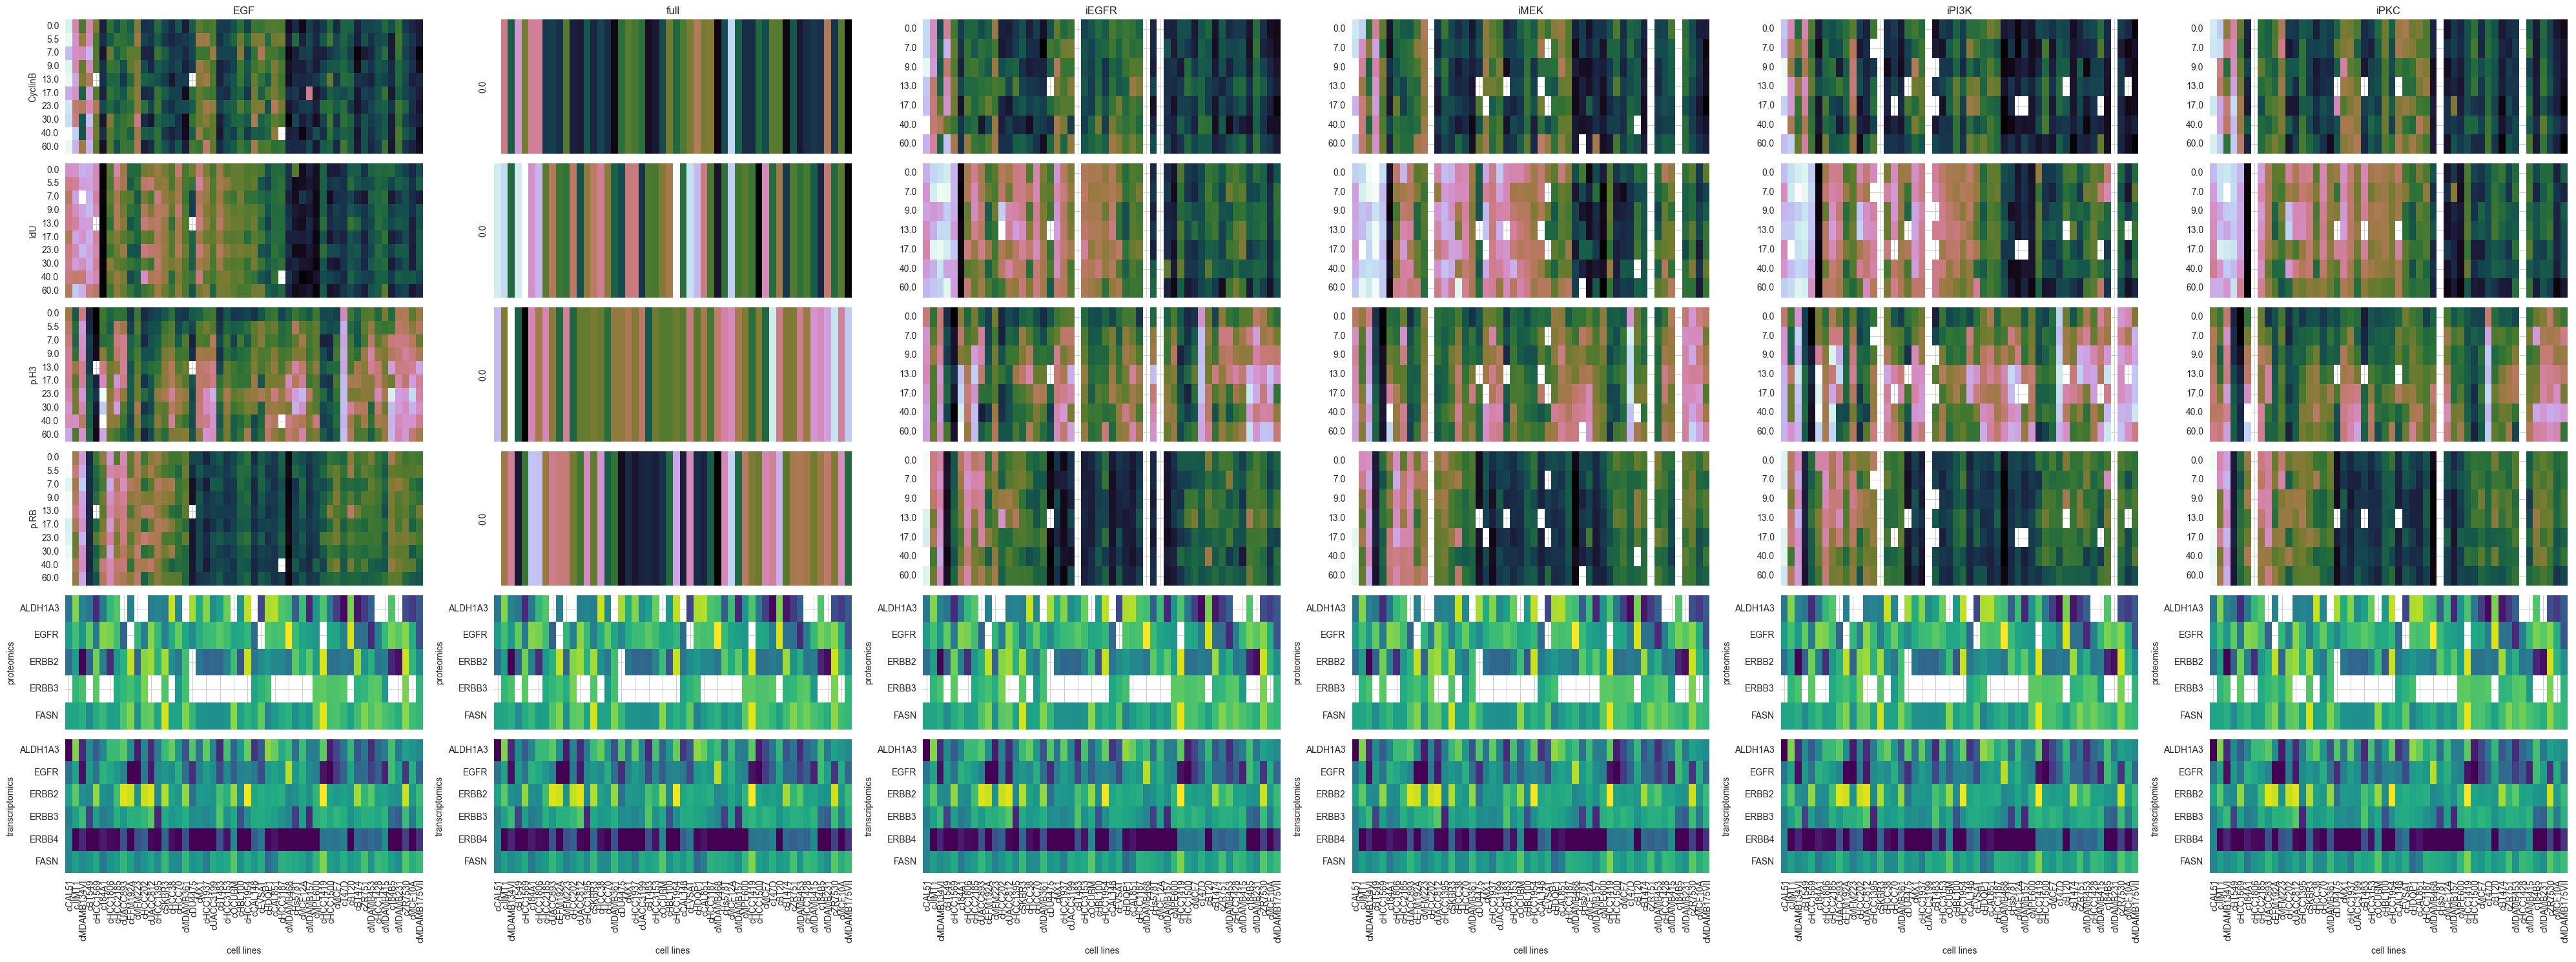

In [16]:
# cell cycle
plot_markers(['CyclinB', 'p.H3', 'p.RB', 'IdU'], ['ALDH1A3', 'FASN', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

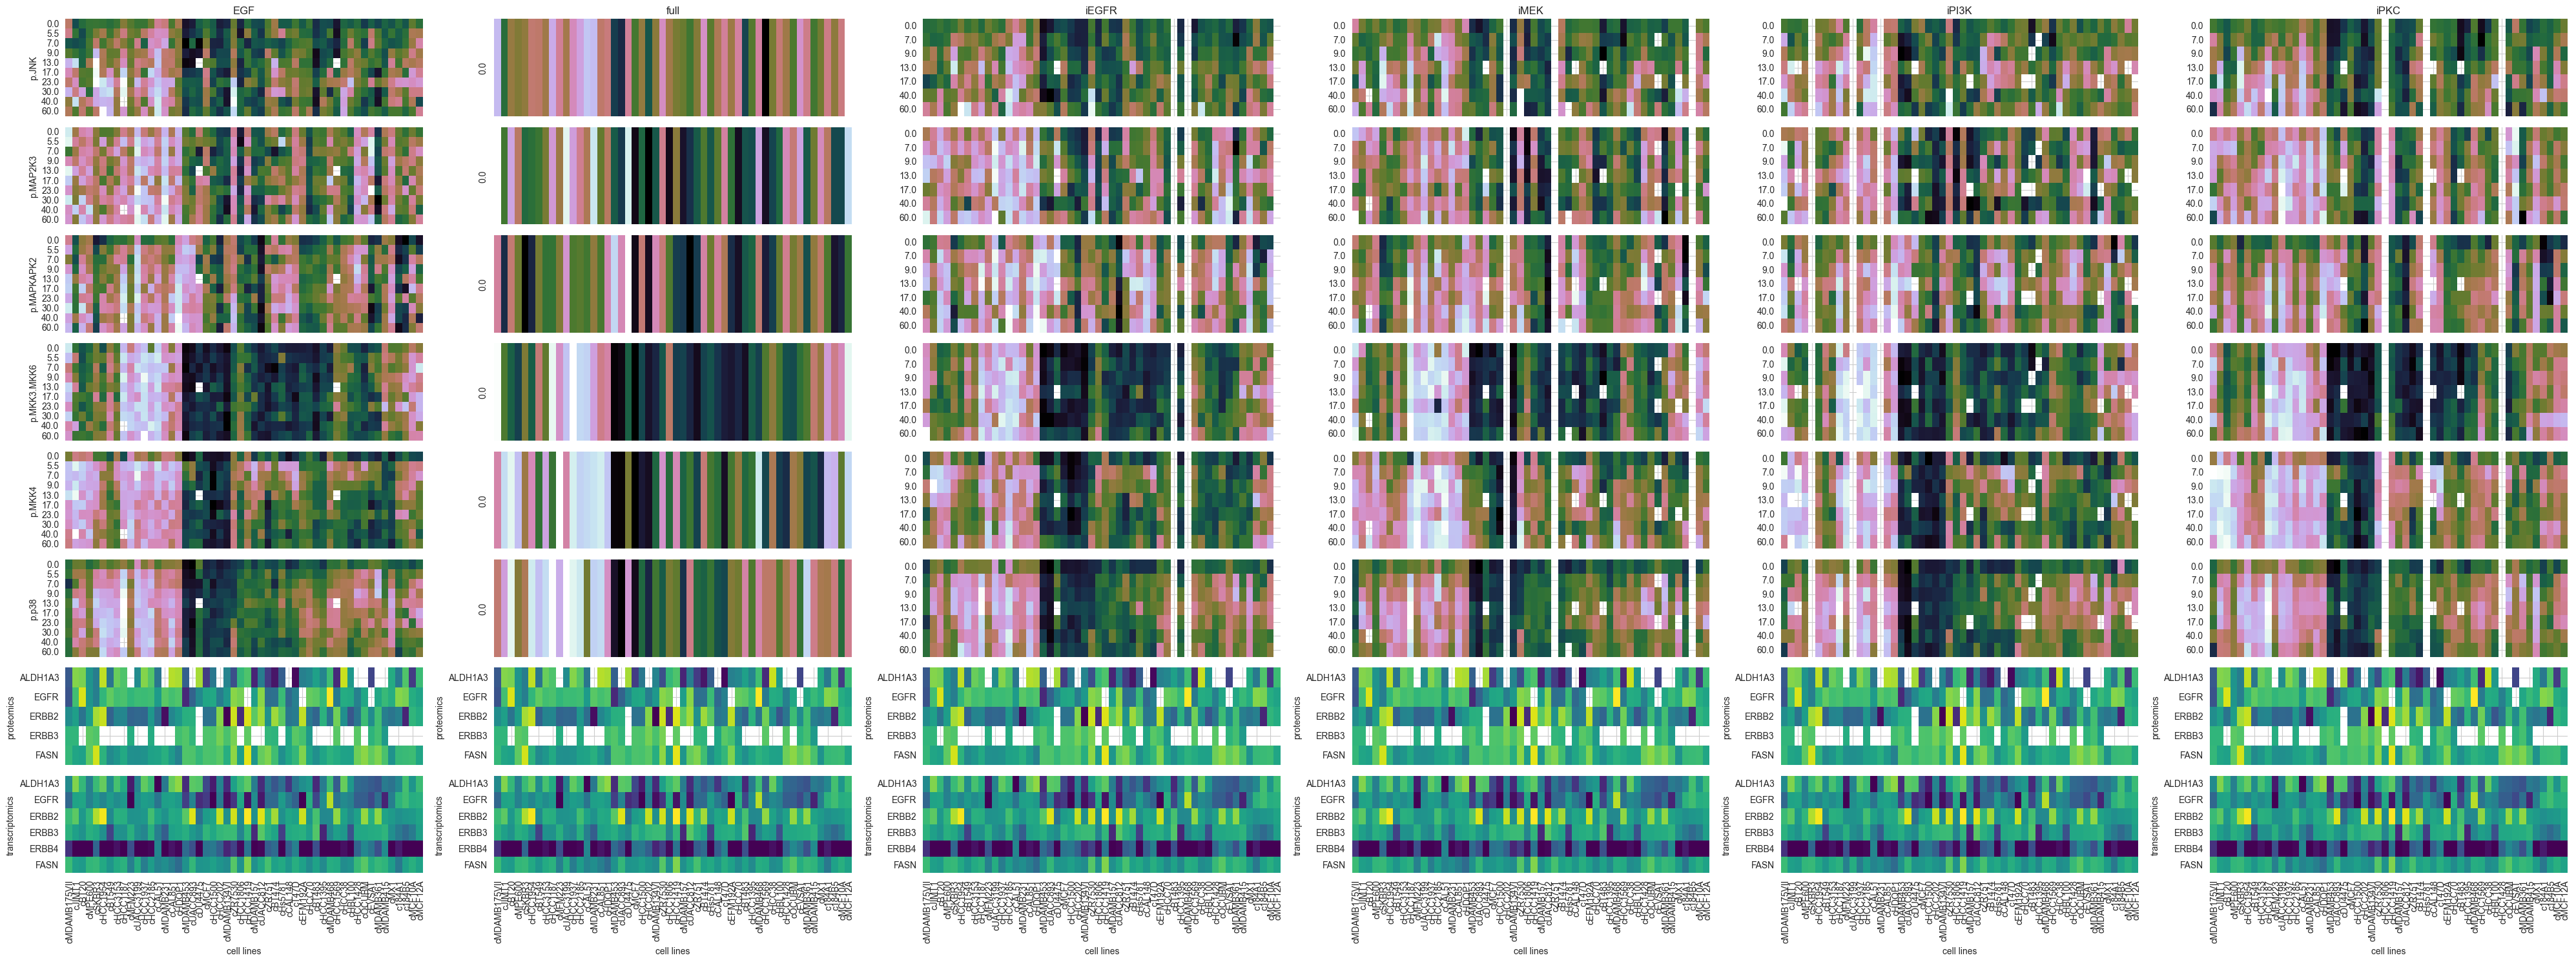

In [17]:
# p38
plot_markers(['p.MKK4', 'p.MAP2K3', 'p.MKK3.MKK6', 'p.p38', 'p.MAPKAPK2', 'p.JNK'], ['ALDH1A3', 'FASN', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

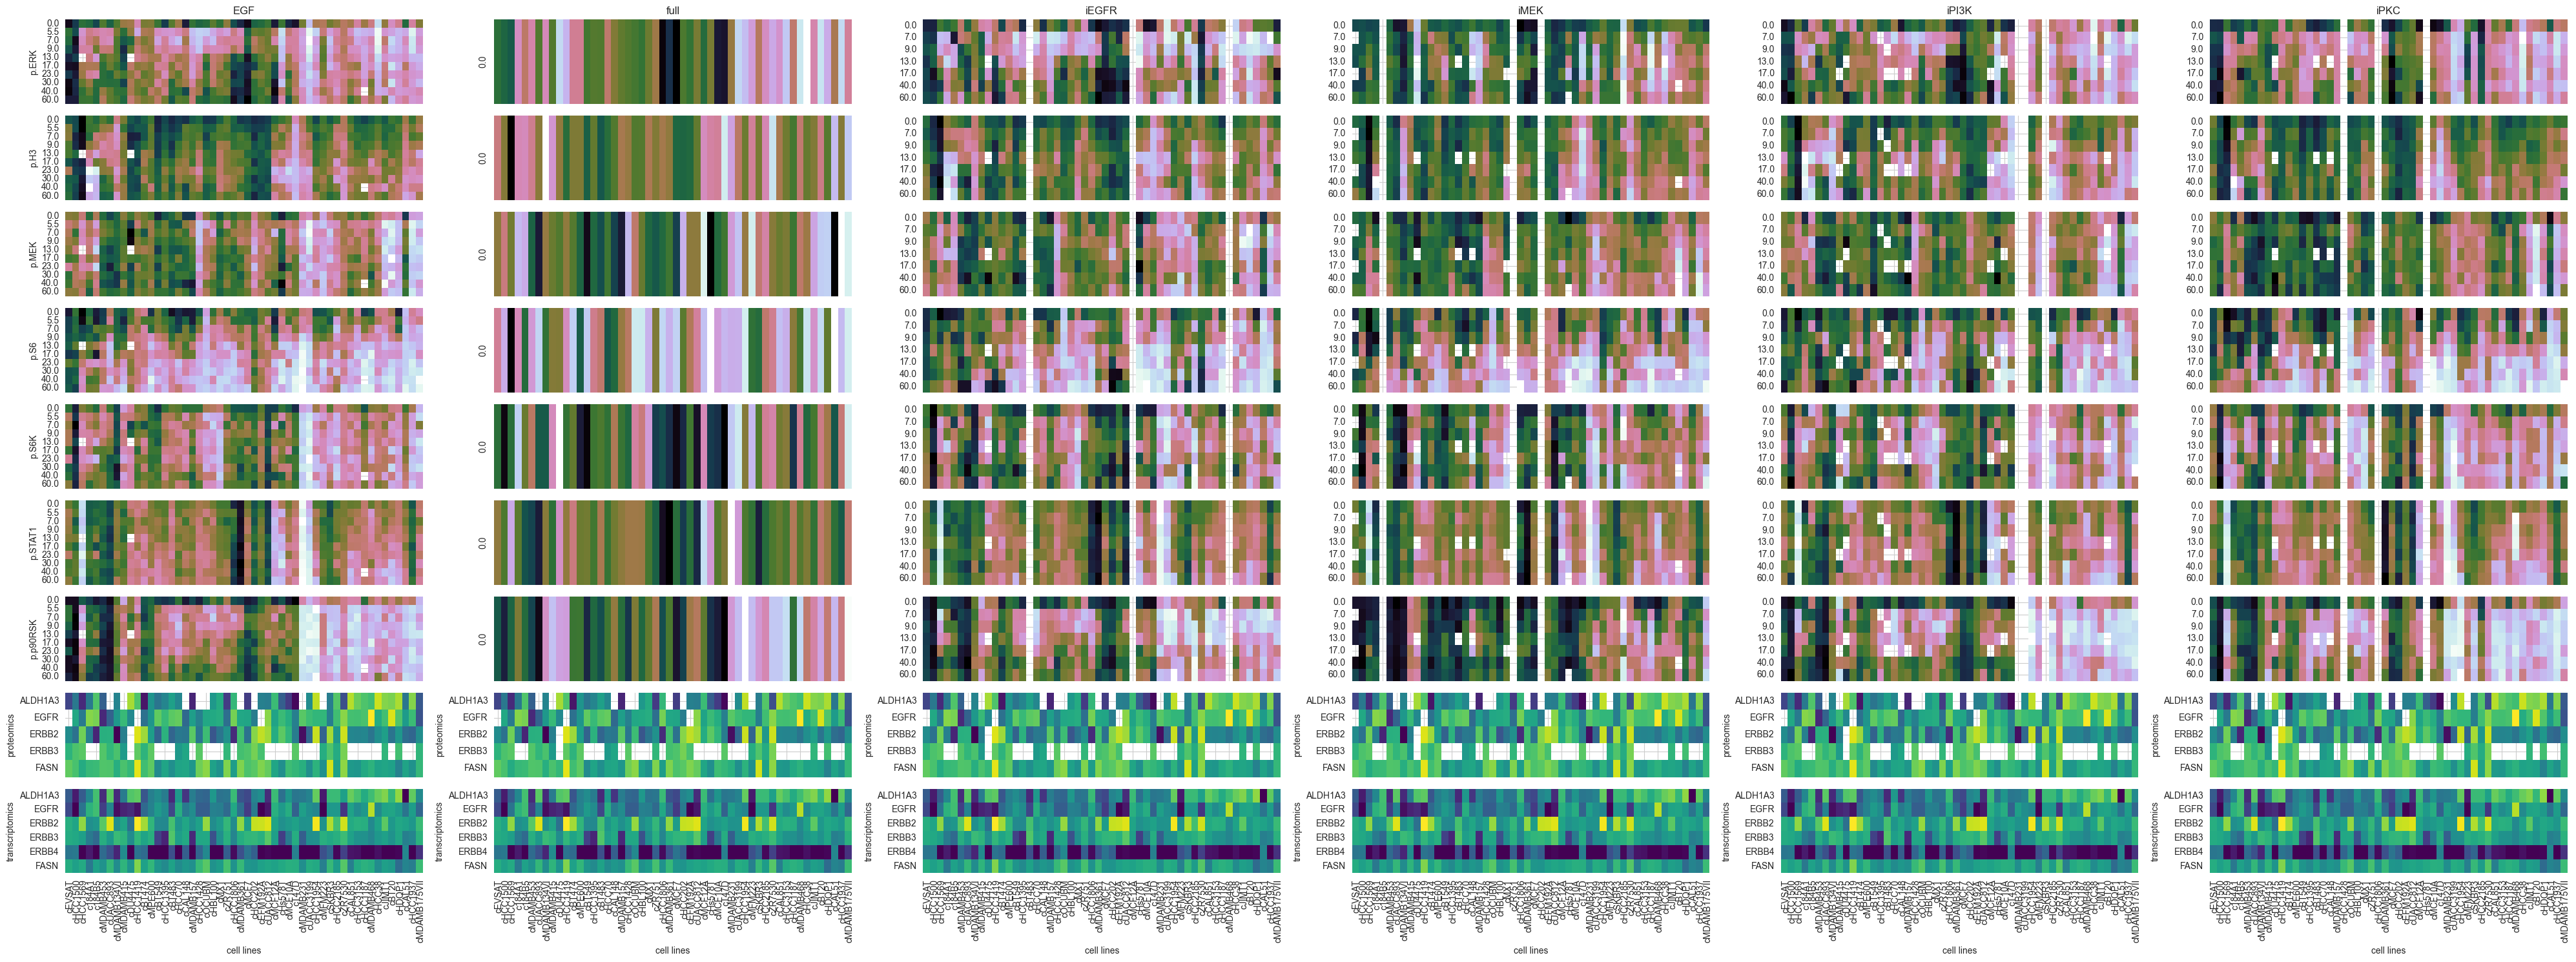

In [18]:
# mapk
plot_markers(['p.MEK', 'p.ERK', 'p.p90RSK',  'p.S6', 'p.S6K', 'p.STAT1', 'p.H3'], ['ALDH1A3', 'FASN', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

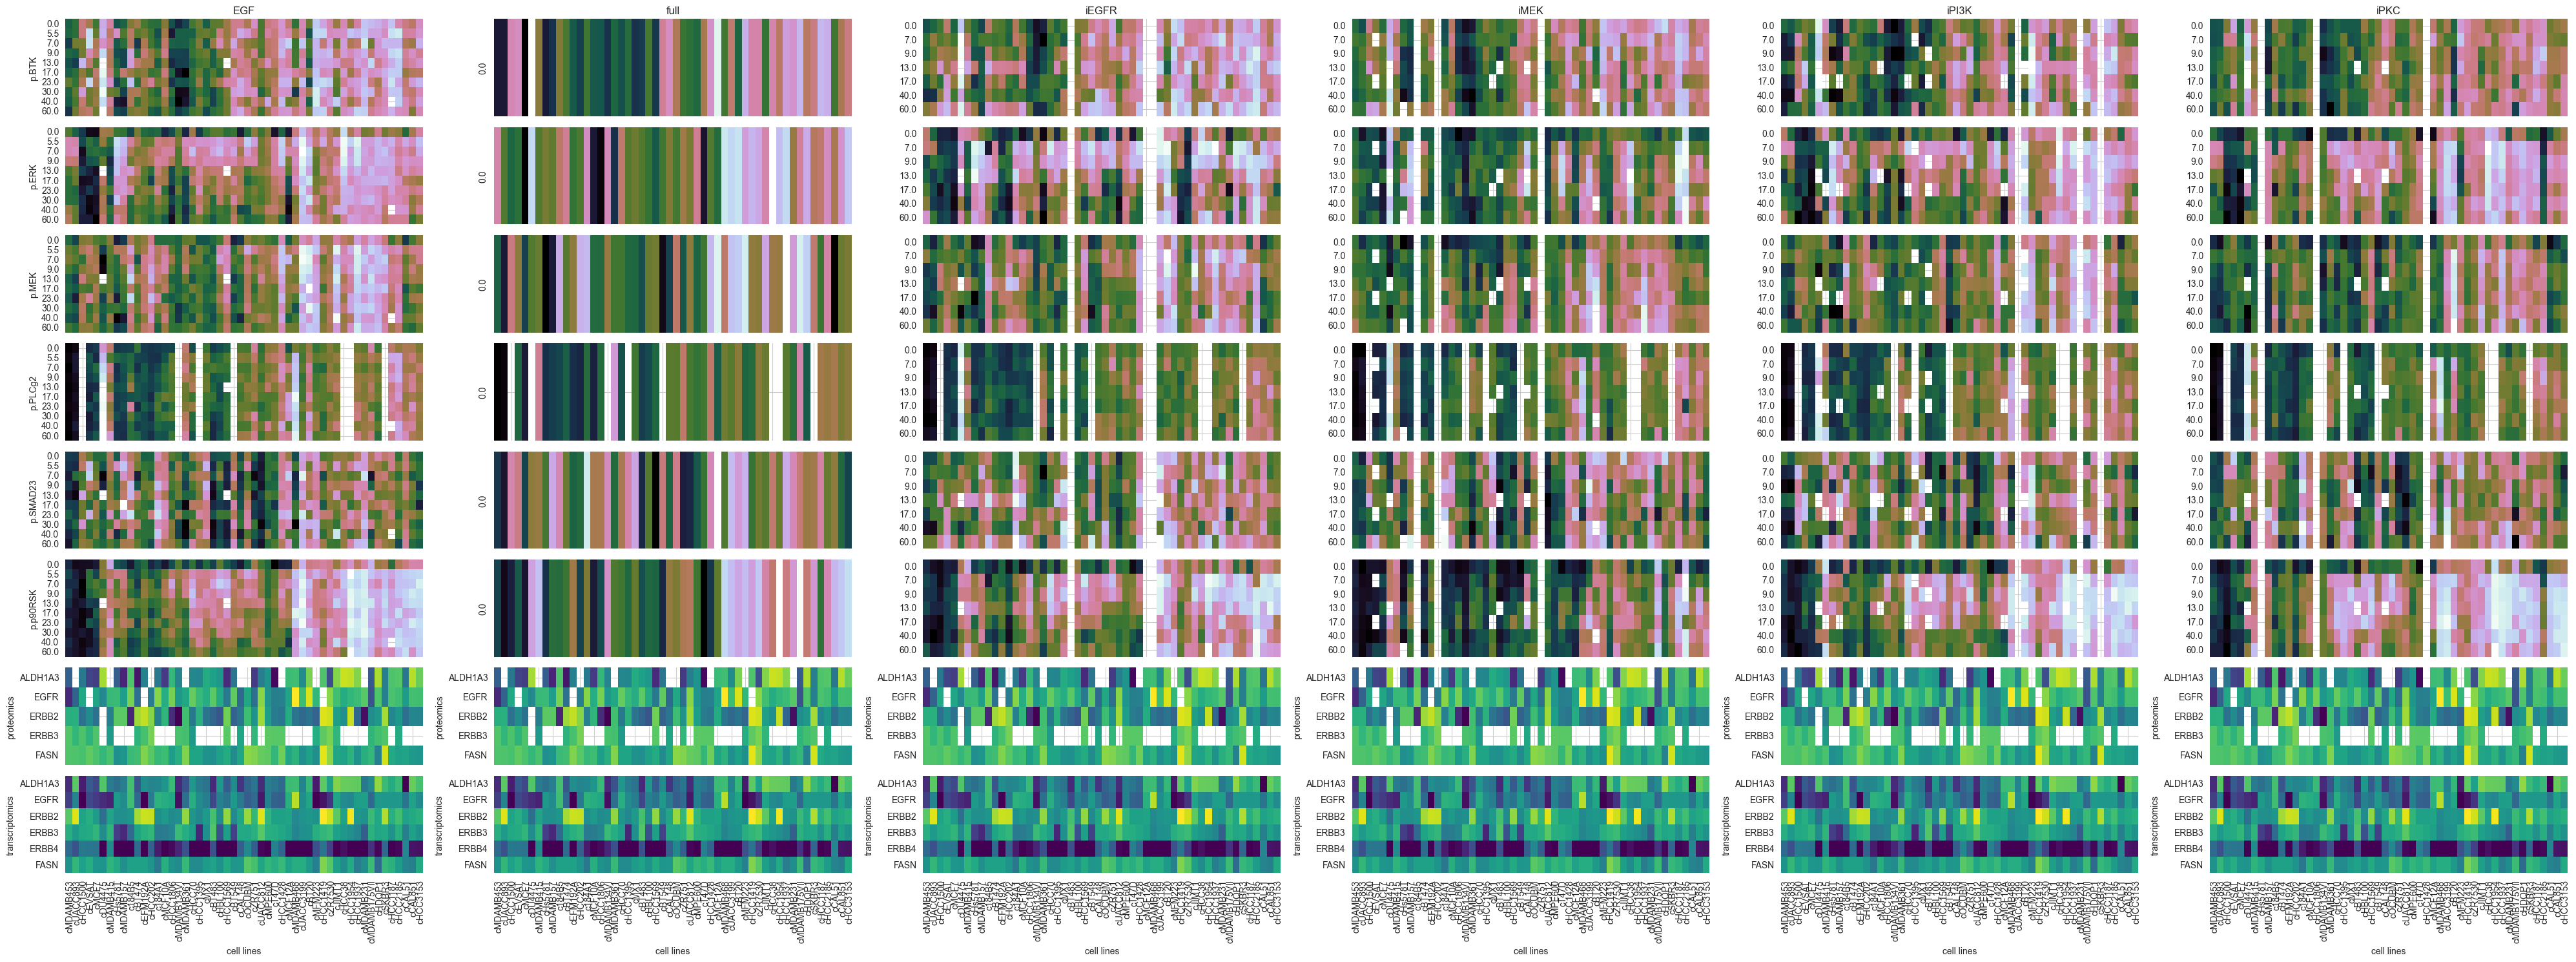

In [19]:
# mapk
plot_markers(['p.MEK', 'p.ERK', 'p.p90RSK',  'p.PLCg2', 'p.BTK', 'p.SMAD23', 'p.FAK'], ['ALDH1A3', 'FASN', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

### HCC1500 hypodiploid https://www.cellosaurus.org/pawefish/BreastCellLineDescriptions/HCC1500.html has lost chromosome 15 (MEK1), MAP2K1 loss (https://cellmodelpassports.sanger.ac.uk/passports/SIDM00879)
### HCC1599 hypertriploid https://www.cellosaurus.org/pawefish/BreastCellLineDescriptions/HCC1599.html has lost chromosome 15 (MEK1), MAP2K2 loss + MAP2K1 gain (https://cellmodelpassports.sanger.ac.uk/passports/SIDM00877)
### EVSAT MAP2K1 loss


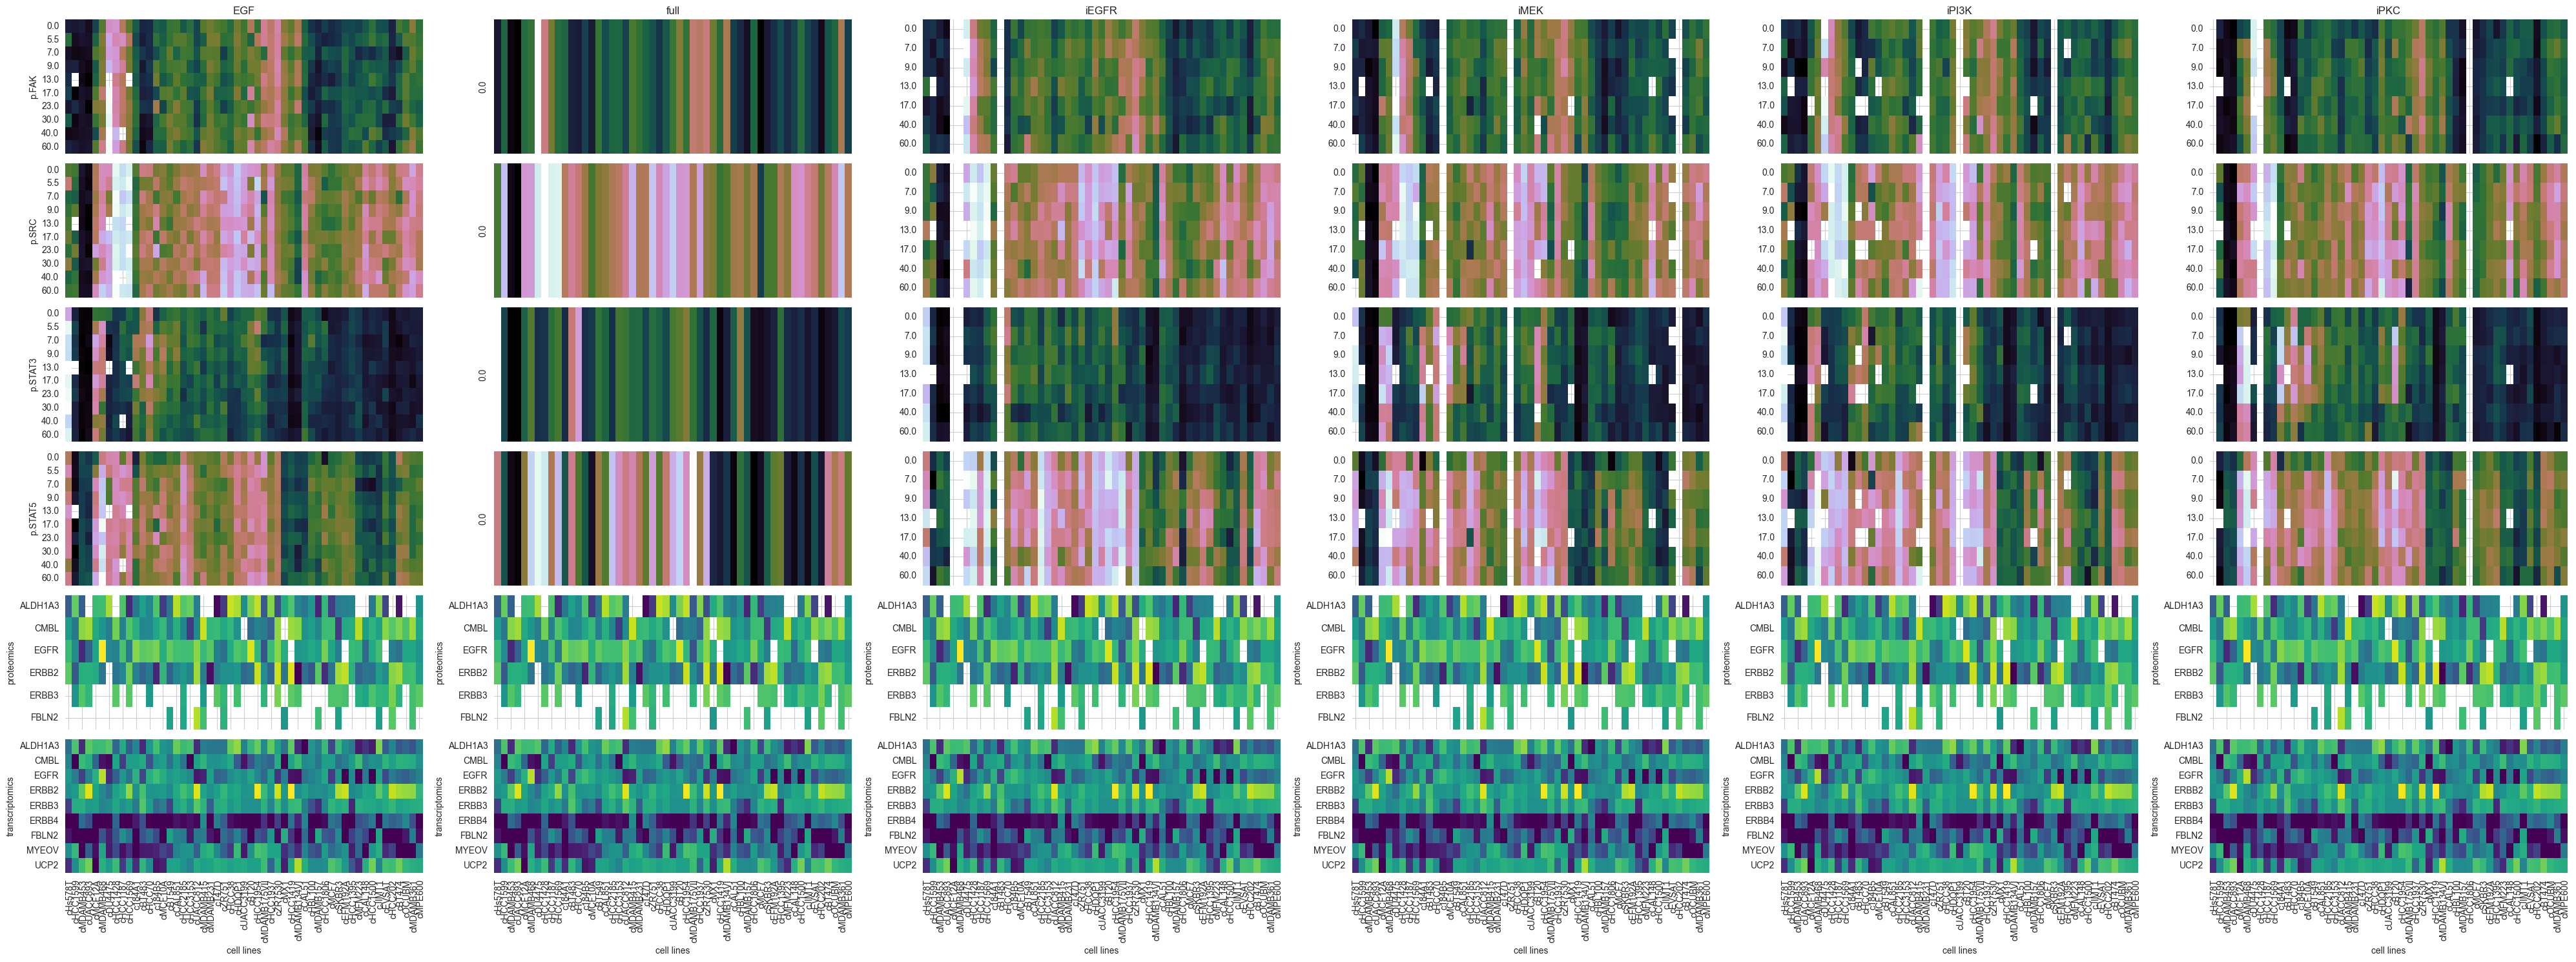

In [447]:
# ecm
plot_markers(['p.SRC', 'p.STAT3', 'p.STAT5', 'p.FAK'], ['ALDH1A3', 'FASN', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

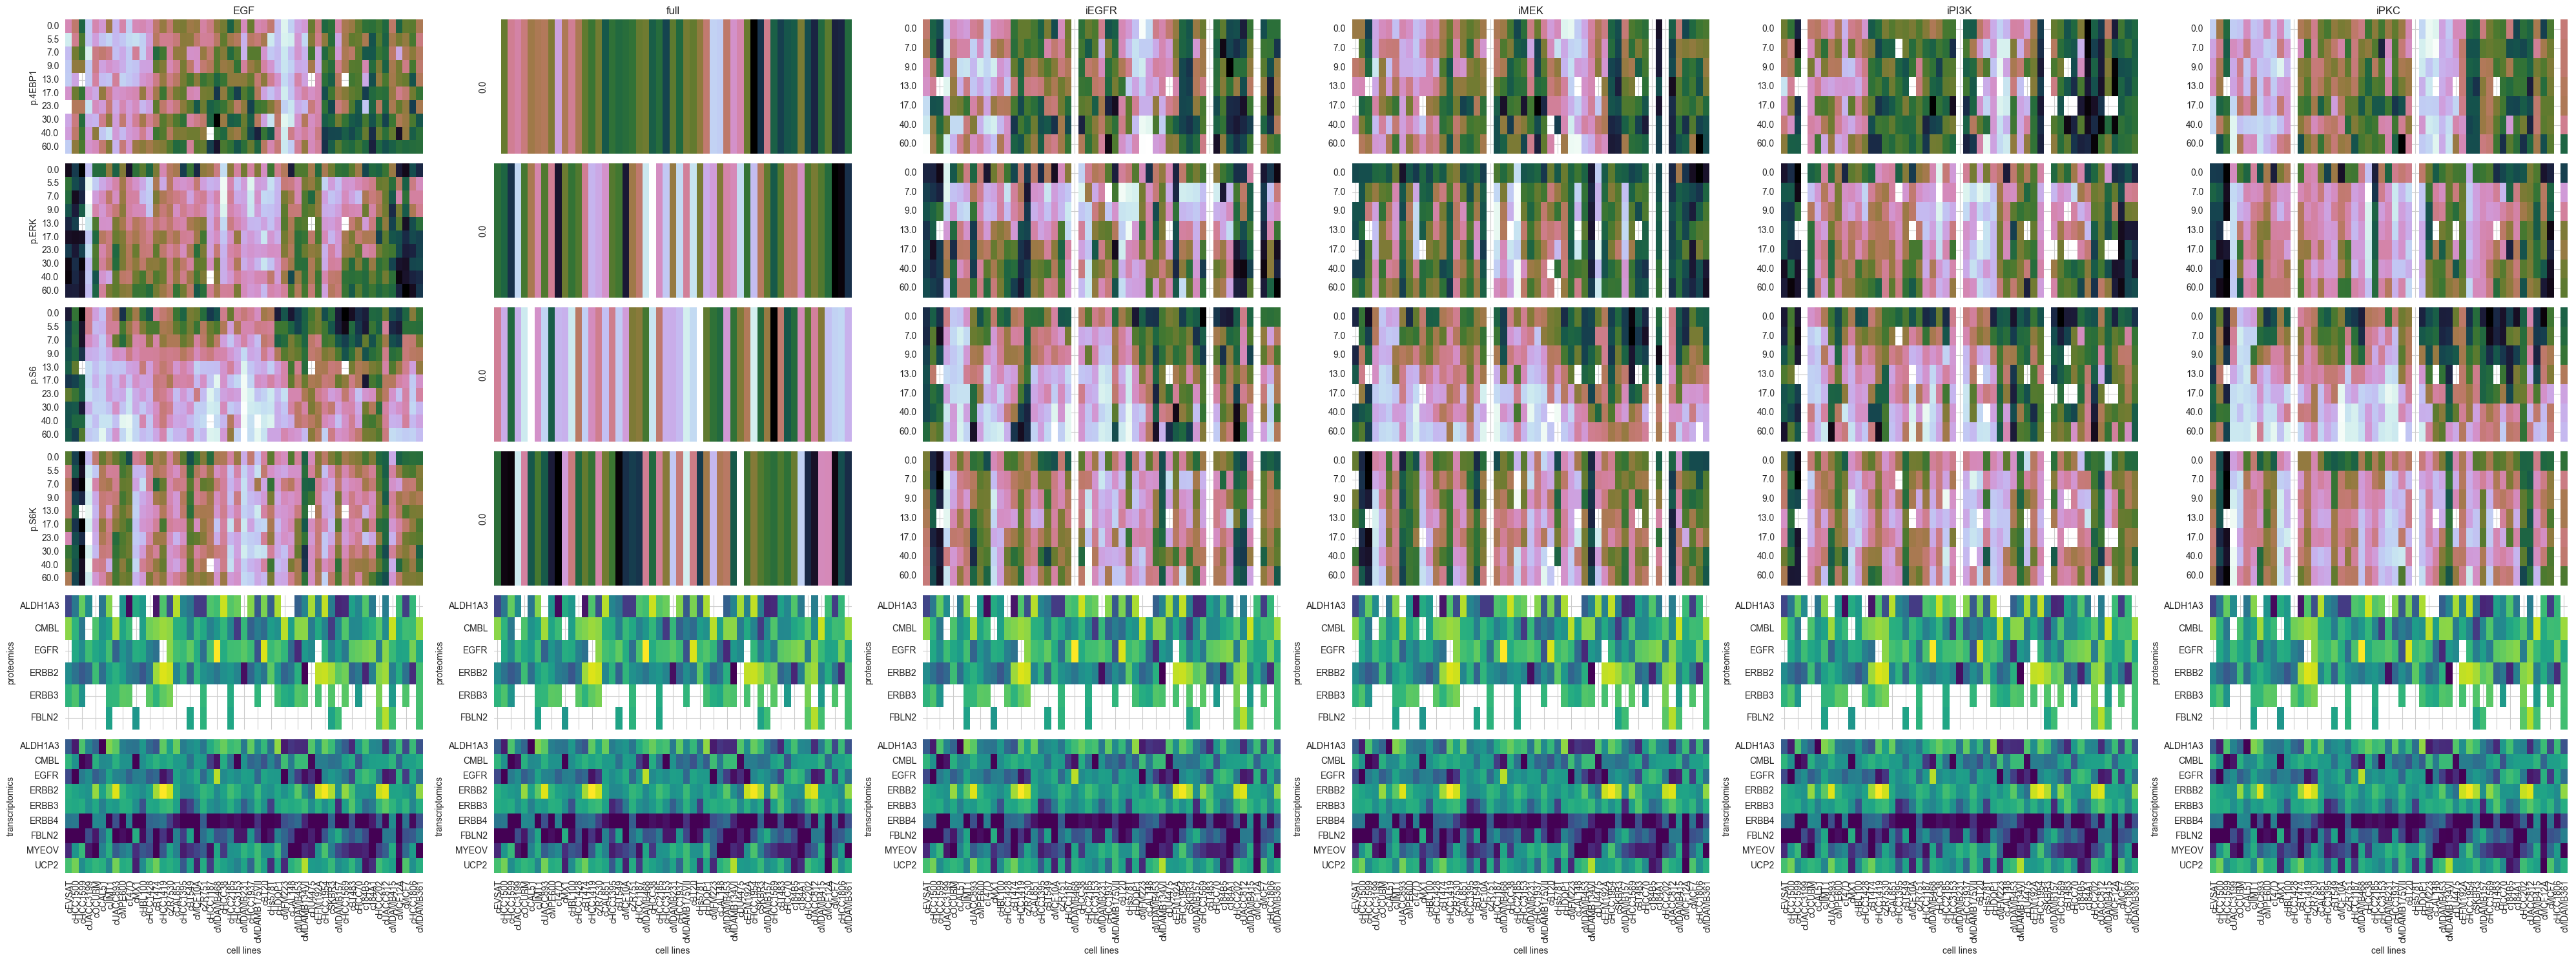

In [448]:
# mTORC1
plot_markers(['p.ERK', 'p.4EBP1', 'p.S6', 'p.S6K'], ['ALDH1A3', 'FASN', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

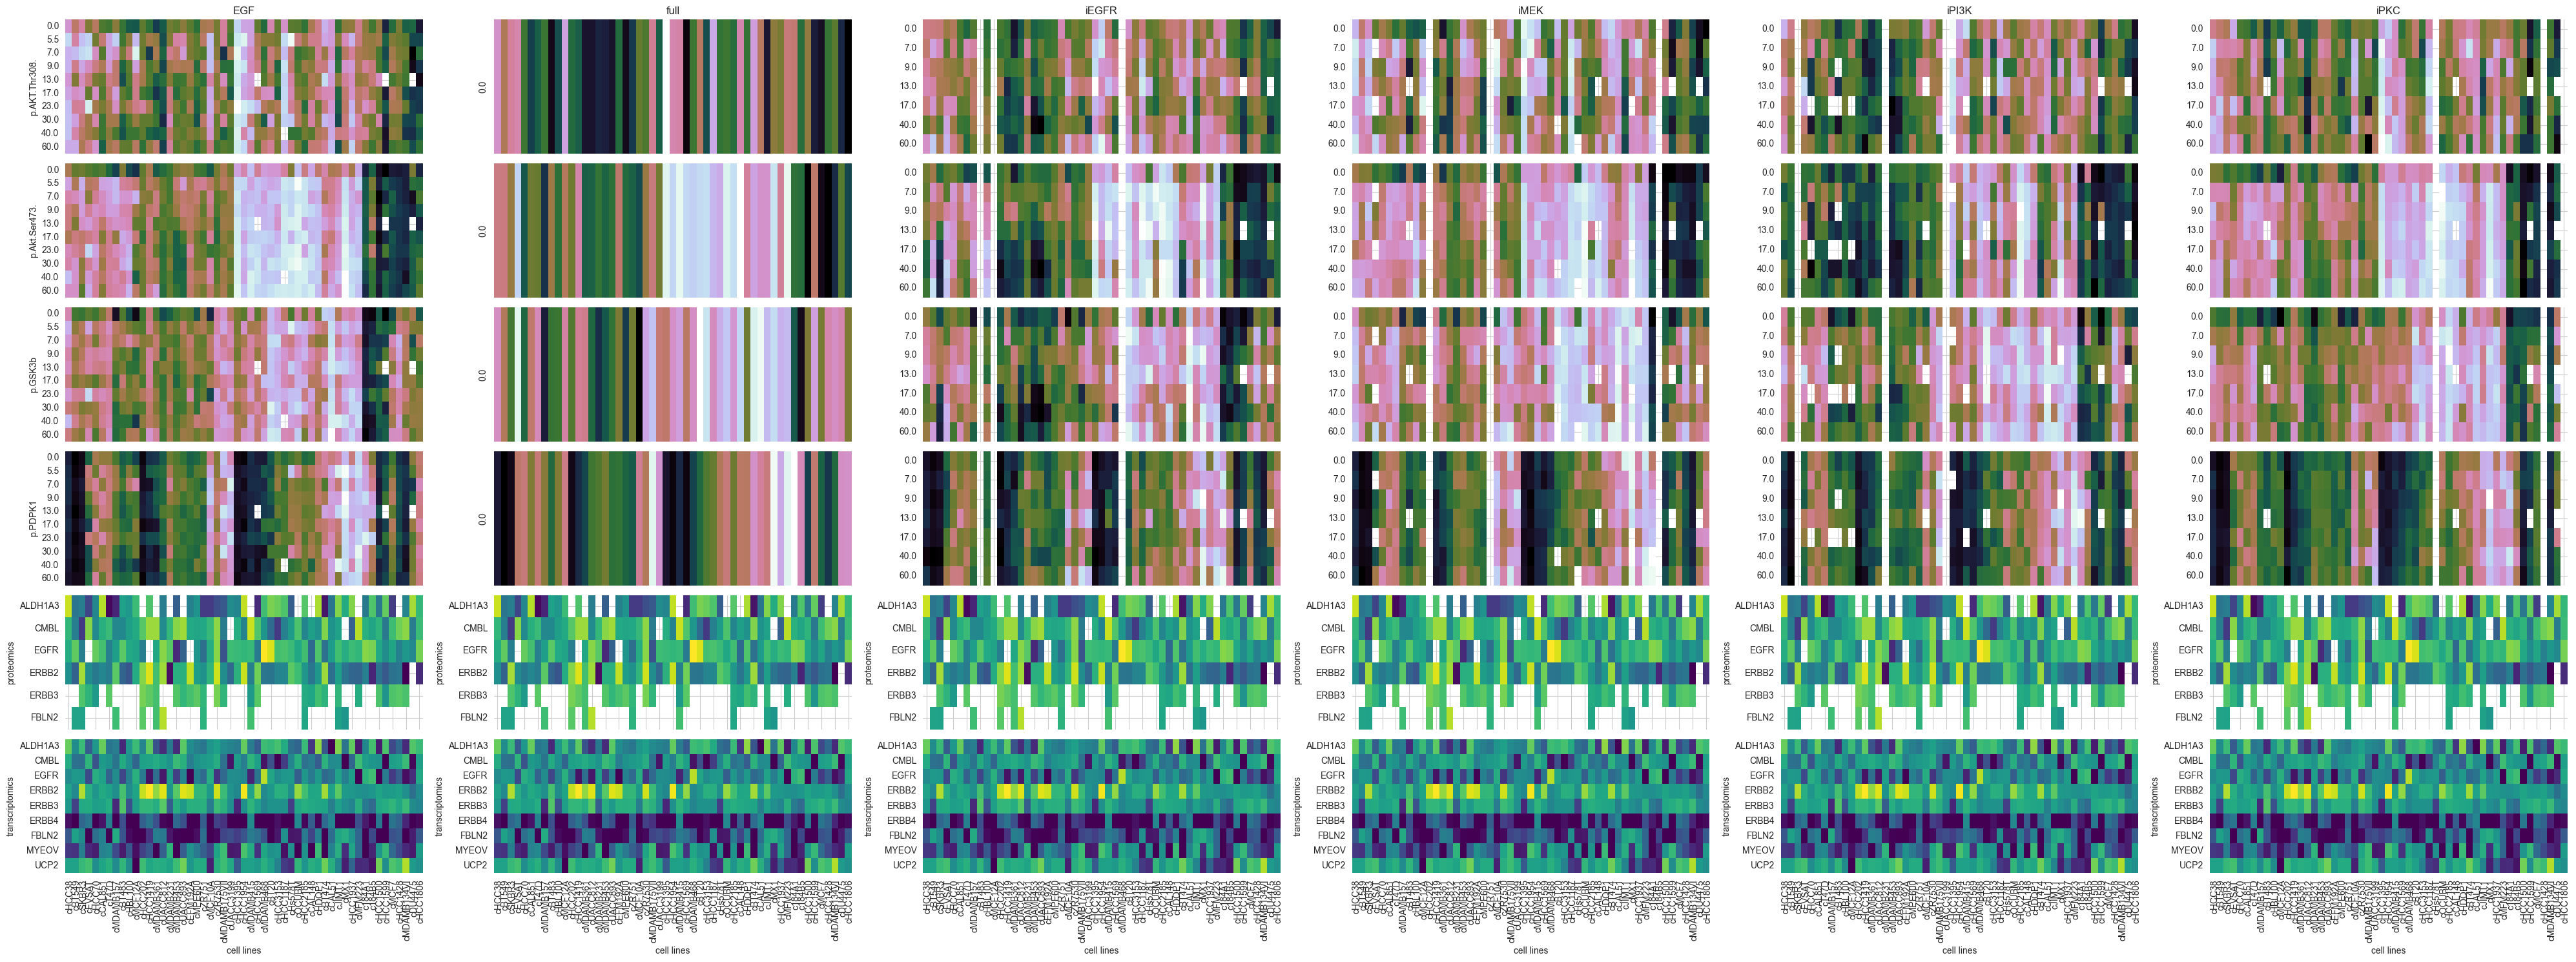

In [449]:
# AKT/mTORC2
plot_markers(['p.AKT.Thr308.', 'p.Akt.Ser473.', 'p.PDPK1', 'p.GSK3b'], ['ALDH1A3', 'FASN', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

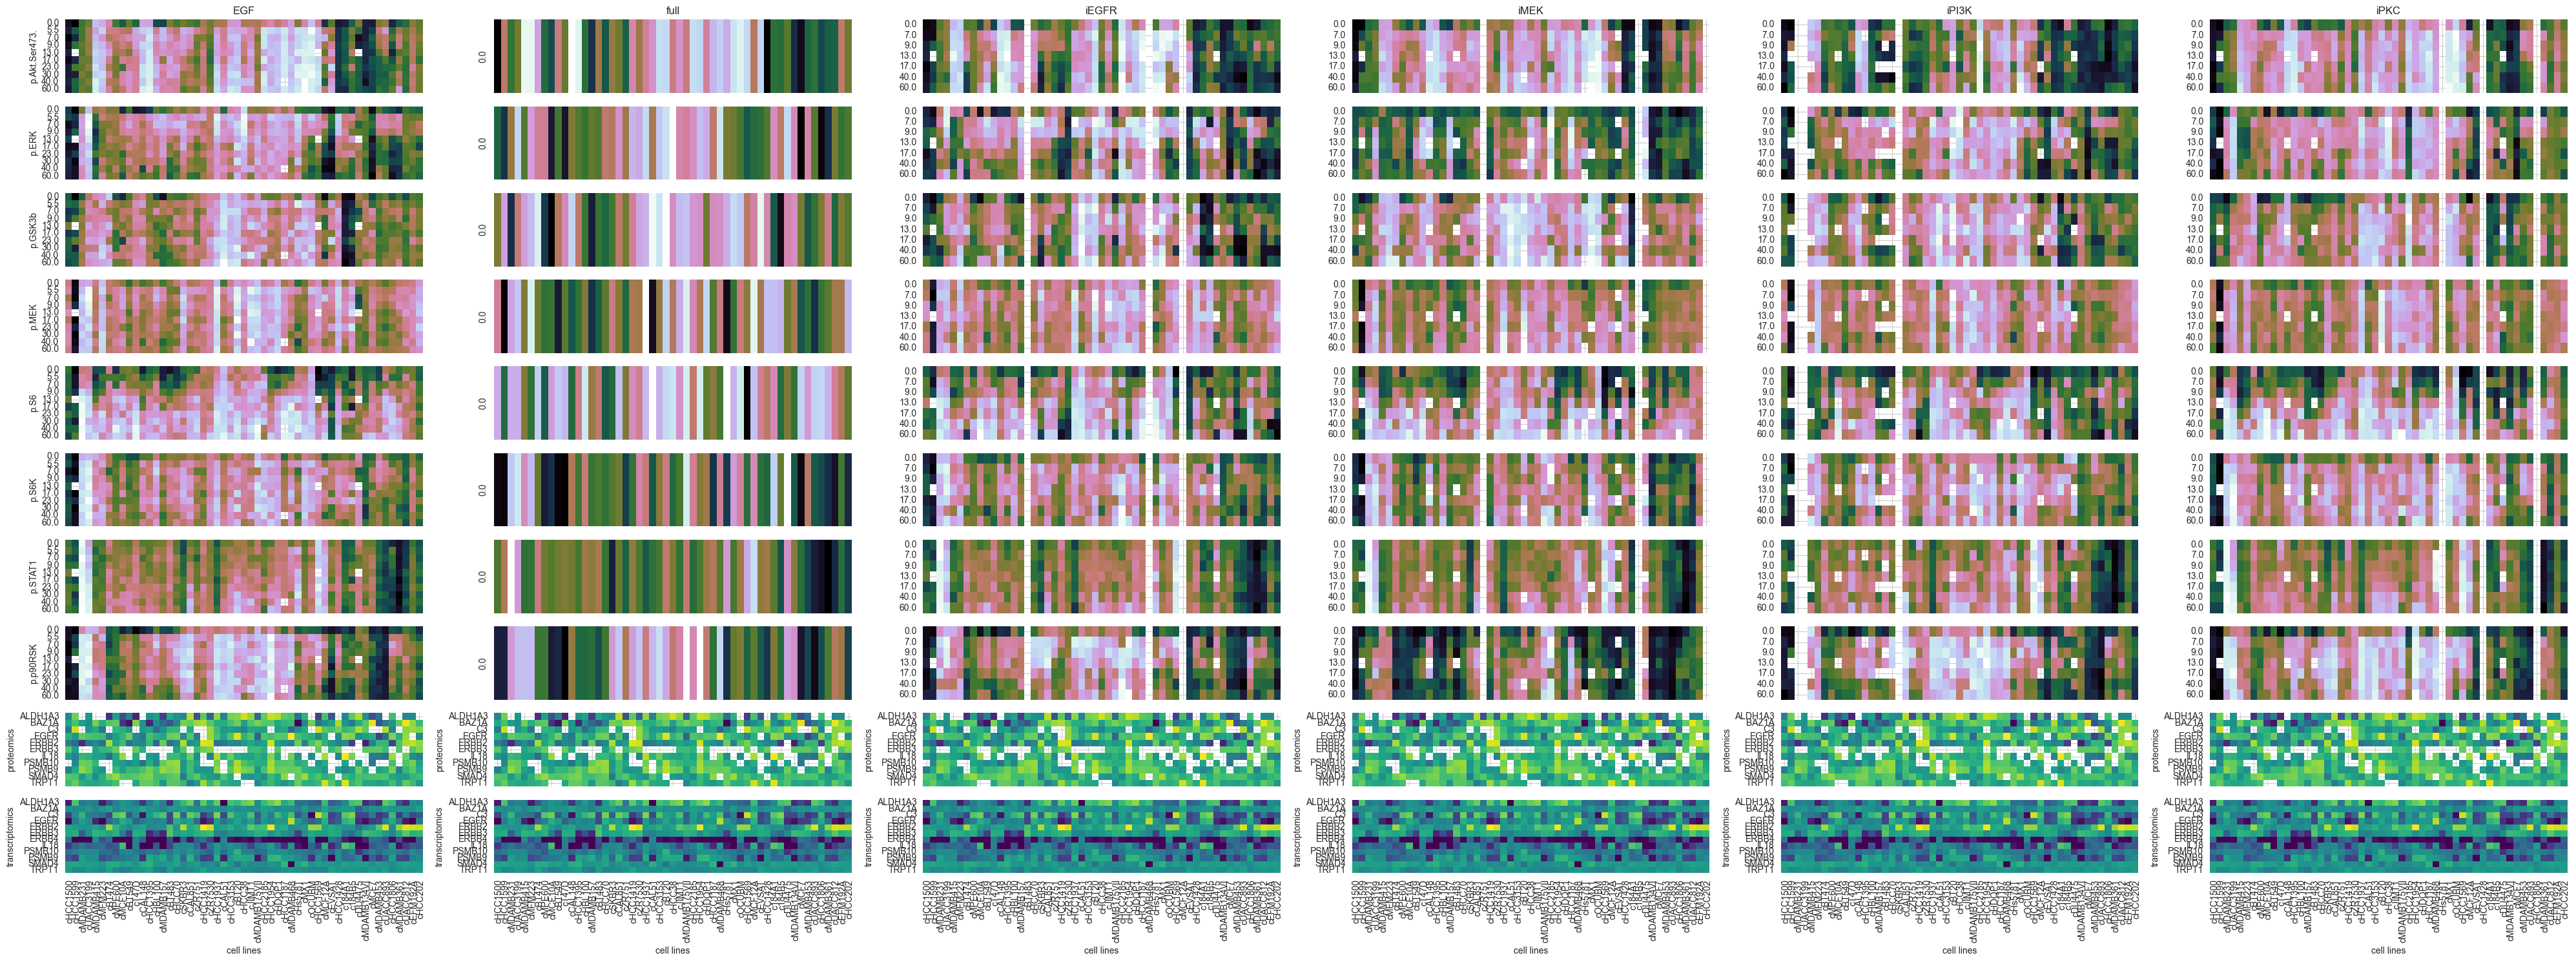

In [452]:
plot_markers(['p.MEK', 'p.ERK', 'p.p90RSK',  'p.S6', 'p.S6K', 'p.STAT1', 'p.Akt.Ser473.', 'p.GSK3b'], ['ALDH1A3', 'C3', 'IL18', 'BAZ1A', 'PSMB10', 'PSMB9', 'SMAD4', 'TRPT1', 'EGFR', 'ERBB2', 'ERBB3', 'ERBB4'])

In [5]:
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
dfm = df[df.observableId.isin(['p.Akt.Ser473.', 'p.AKT.Thr308.', 'p.PDK1', 'p.GSK3b', 'p.p90RSK', 'p.SRC', 'p.ERK', 'p.MKK3.MKK6', 'p.MKK4', 'p.p38', 'p.JNK', 'p.HER2', 'p.PDPK1', 'p.MEK'])]
dfp = dfm[dfm.treatment=='EGF'].pivot_table(index=['time', 'observableId'], columns='preequilibrationConditionId', values='measurement').reset_index()

In [6]:
from scipy.stats import zscore
dfz = dfp.groupby('observableId').agg("min").drop(columns='time').T.apply(zscore, nan_policy='omit')
dfz

observableId,p.AKT.Thr308.,p.Akt.Ser473.,p.ERK,p.GSK3b,p.HER2,p.JNK,p.MEK,p.MKK3.MKK6,p.MKK4,p.PDPK1,p.SRC,p.p38,p.p90RSK
preequilibrationConditionId,,,,,,,,,,,,,
c184A1,0.583363,-1.338500,-0.127061,-2.144669,0.177547,0.106176,-0.394421,0.097714,-0.265022,1.505288,-0.830695,-0.642836,-0.685497
c184B5,-0.035301,-0.598112,-0.653067,-2.038924,0.677766,-0.001923,0.809473,0.541922,0.317676,0.770093,-0.510693,0.015618,-1.128811
cBT20,0.577398,1.394766,1.806448,1.894294,0.905580,-0.237684,1.229054,-0.275812,1.640515,-0.610023,0.084903,1.050046,1.188589
cBT474,0.761726,0.525911,0.375145,0.428819,1.215240,-0.021374,-0.551930,-1.291938,-0.059642,0.455189,-0.733691,-1.080773,-0.707641
cBT483,-0.817128,0.249924,-0.381553,-0.393496,NaN,-1.594580,-0.648356,-1.071198,-0.382447,-0.490514,-0.030043,-0.232228,-0.633885
cBT549,0.552072,0.068950,0.154867,-0.155843,0.057025,0.543323,-1.143848,0.794888,-0.140829,-1.565725,-0.571226,0.770569,-0.658629
cCAL148,0.182116,1.497498,-1.226570,0.626911,0.312849,-0.429585,-1.103691,-0.861664,-1.213078,-0.046836,0.369367,-1.073819,-1.098318
cCAL51,1.746515,0.530955,-0.101287,2.164317,1.236475,2.706948,-0.889897,2.209282,1.095232,1.365630,0.527677,0.712053,1.182581
cCAL851,-0.549988,-0.040362,0.136596,0.274872,0.108923,0.757322,-0.265084,0.818420,1.453091,0.602617,-0.413618,1.317067,1.447655


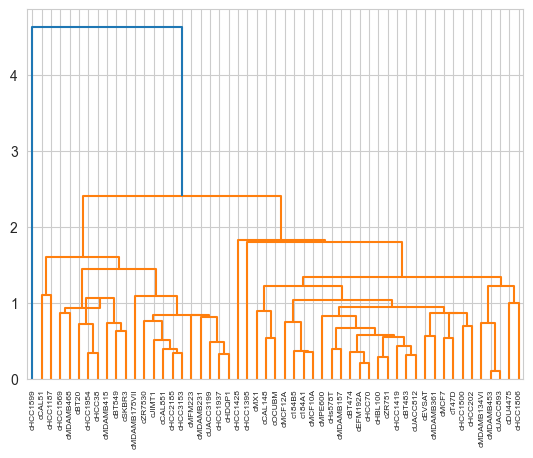

In [11]:
distance_matrix = pdist(dfz, metric=nan_euclidean)
linkage_matrix = linkage(distance_matrix, method='centroid')
d = dendrogram(linkage_matrix, labels=dfz.index)

In [8]:
pmarkers = [
    'ALDH1A3',
    'EGFR',
    'PBK', # MEK independent ERK activator
    'IKBKE', # PDK1 independent AKT activator
    'SOS1', # second messenger
    'GRB2', # adaptor
    'GAB1', # adaptor
    'MAPK1', # ERK2
    'MAPK3', # ERK1
    'MAP2K1', # MEK1
    'MAP2K2', # MEK2
    'GSK3B', # GSK3b
    'ERBB2', # ERBB2
    'MAPK8', # JNK1
    'MAPK9', # JNK2
    'MAPK10', # JNK3
    'MAP2K3', # MKK3
    'MAP2K6', # MKK6
    'MAP2K4', # MKK4
    'PDPK1', # PDPK1
    'SRC', # SRC
    'MAPK11', # p38beta
    'MAPK12', # p38gamma
    'MAPK13', # p38delta
    'MAPK14', # p38alpha
    'RPS6KA1', # p90RSK
    'RPS6KA2', # p90RSK
]

# pmarkers = [
#     'CCDC78',
#  'RNF41',
#  'CDC14B',
#  'KIAA1257',
#  'PPP1R15B',
#  'VCL',
#  'GJA5',
#  'FAHD1',
#  'C18orf32',
#  'CCDC87',
#  'S100A4',
#  'CERS6',
#  'ANTXR1',
#  'PLS3',
#  'SPECC1',
#  'GNA13',
#  'RELB',
#  'ABCC8',
#  'HLA.DMB',
#  'GBP1',
#  'YWHAE',
# ]
#
df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx[df_tx['observableId'].isin(pmarkers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
).T.apply(zscore, nan_policy='omit').T

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px[df_px['observableId'].isin(pmarkers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
).T.apply(zscore, nan_policy='omit').T

In [9]:
import synapseclient

syn = synapseclient.Synapse()
syn.login()
file_id_table = pd.read_csv(
    syn.get("syn20631269").path, index_col=0
).set_index("fileID")
df_annotation = file_id_table[['PAM50', 'Neve', 'Marcotte', 'Gene.cluster', 'Classification', 'primary.tumor', 'formed.mets', 'Growth.medium', 'Origin', 'AR', 'PGR', 'HER2', 'ERa', 'Lehmann', 'Ethnicity', 'cell_line']].groupby('cell_line').agg(
    lambda x: ' '.join(np.unique([str(x) for x in x]))
).reset_index()
df_annotation['cell_line'] = df_annotation['cell_line'].apply(lambda x: f'c{x}')
df_annotation = df_annotation.set_index('cell_line').apply(lambda x: x.astype('category'))
cat = df_annotation.apply(lambda x: x.cat.codes)

Welcome, Fabian Froehlich!

[syn20631269:FileID_table.csv]: Found existing file at /Users/frohlif/.synapseCache/298/42318298/FileID_table.csv, skipping download.


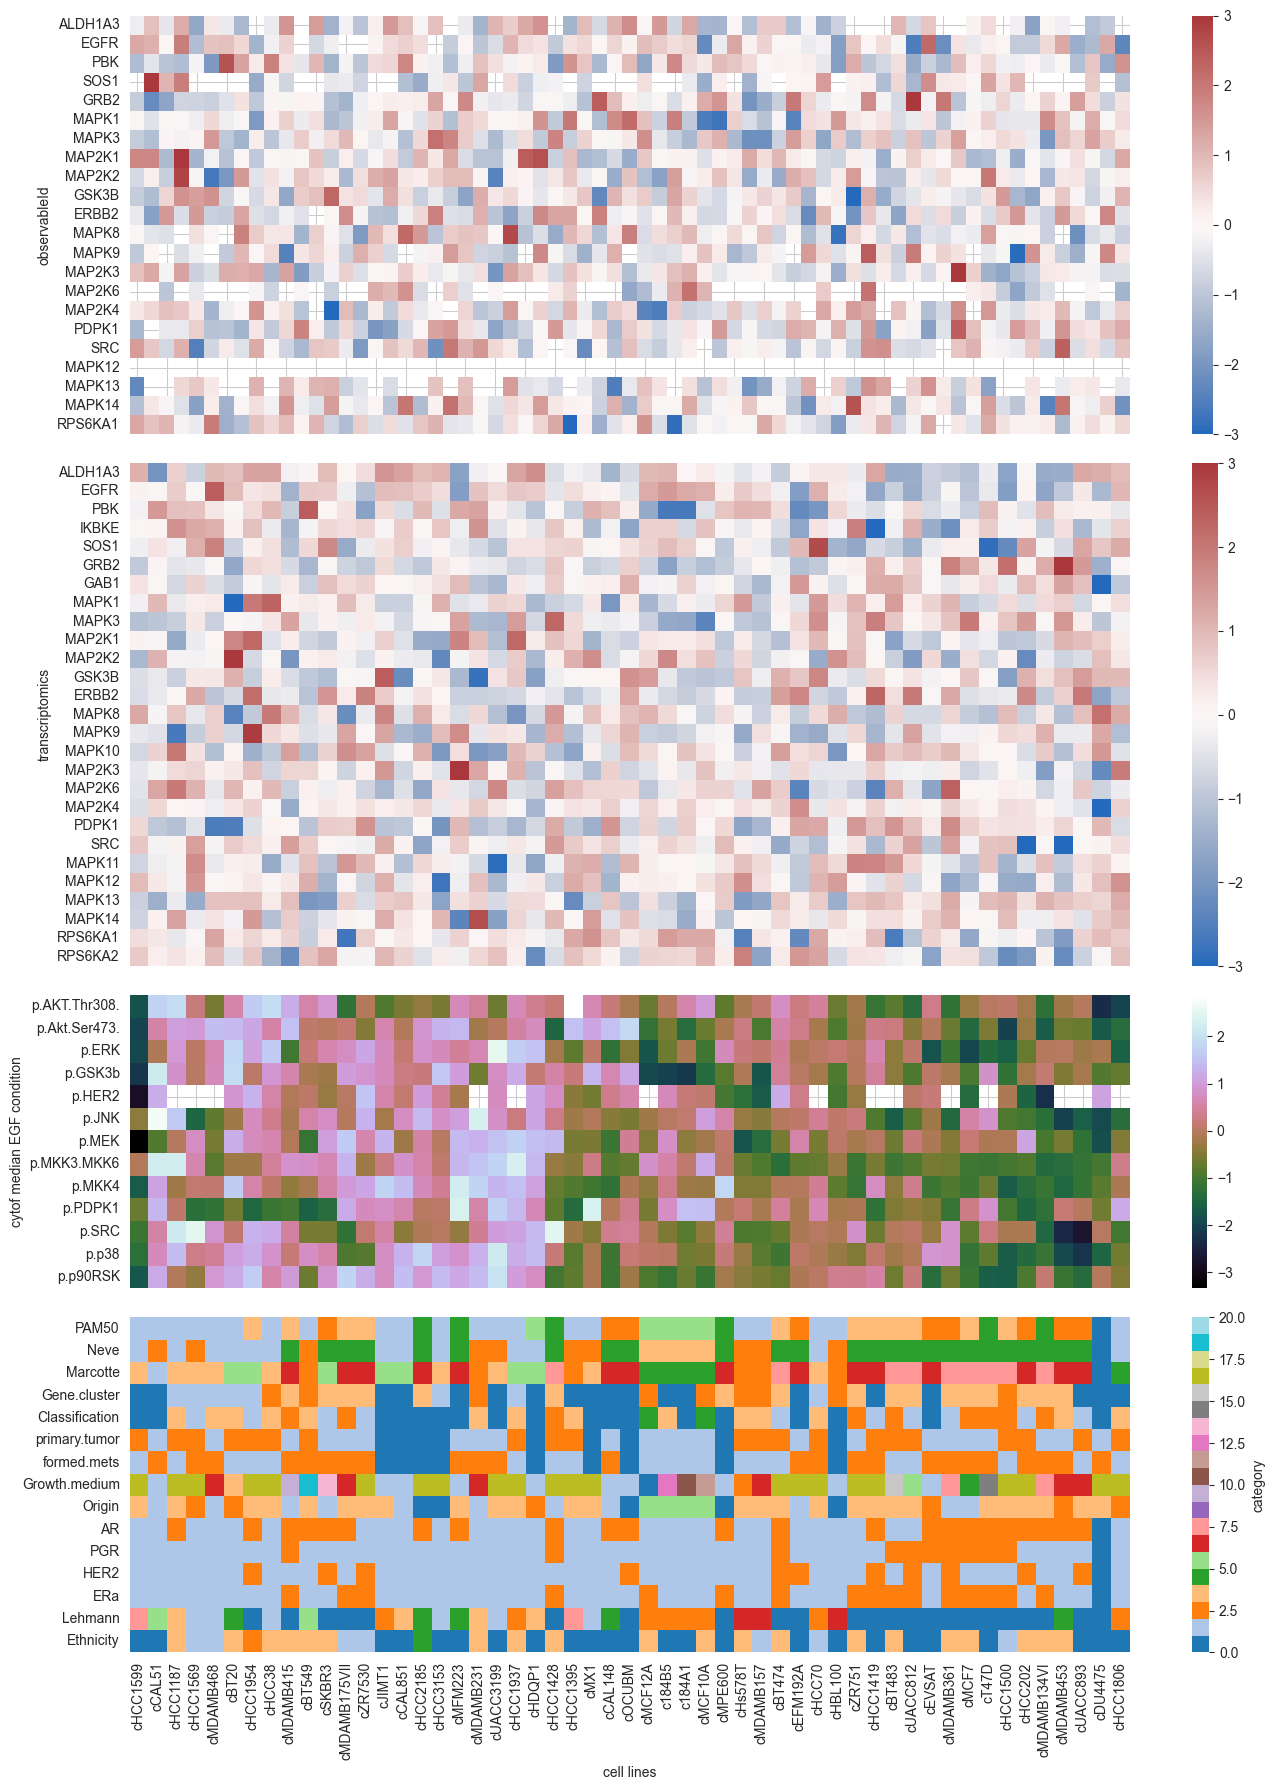

In [10]:
fig, ax = plt.subplots(figsize=(14, 18), nrows=4, height_ratios=[1, 1.2, 0.7, 0.8])

sns.heatmap(
    df_px.loc[[m for m in pmarkers if m in df_px.index]], cmap='vlag', ax=ax[0], vmax=3, vmin=-3
)
ax[0].set_xticklabels([])
ax[2].set_ylabel('proteomics')
ax[0].set_xlabel('')
sns.heatmap(
    df_tx.loc[[m for m in pmarkers if m in df_tx.index],d['ivl']], cmap='vlag', ax=ax[1], vmax=3, vmin=-3
)
ax[1].set_xticklabels([])
ax[1].set_ylabel('transcriptomics')
ax[1].set_xlabel('')
sns.heatmap(
    dfz.loc[d['ivl'],:].T, cmap='cubehelix', ax=ax[2]
)
ax[2].set_xticklabels([])
ax[2].set_ylabel('cytof median EGF condition')
ax[2].set_xlabel('')
sns.heatmap(
    cat.loc[d['ivl'],:].T, cmap='tab20', ax=ax[3], cbar_kws={'label': 'category'}, vmin=0, vmax=20
)
ax[3].set_xlabel('cell lines')
plt.tight_layout()

In [418]:
{
    col: {cat: code for code, cat in enumerate(df_annotation[col].cat.categories)}
    for col in df_annotation.columns
}

{'PAM50': {'0': 0,
  'Basal': 1,
  'HER2': 2,
  'Luminal A': 3,
  'Luminal B': 4,
  'Normal': 5},
 'Neve': {'0': 0, 'Basal A': 1, 'Basal B': 2, 'Immortalized': 3, 'Luminal': 4},
 'Marcotte': {'0': 0,
  'Basal 1': 1,
  'Basal 2': 2,
  'Basal 3': 3,
  'Basal 4': 4,
  'Basal 5': 5,
  'Luminal 1': 6,
  'Luminal 2': 7},
 'Gene.cluster': {'0': 0, 'BaA': 1, 'BaB': 2, 'Lu': 3},
 'Classification': {'0': 0, 'HER2': 1, 'HR+': 2, 'TNBC': 3, 'normal': 4},
 'primary.tumor': {'0': 0, 'no': 1, 'yes': 2},
 'formed.mets': {'0': 0, 'no': 1, 'yes': 2},
 'Growth.medium': {"1:1 DMEM:Ham's F12 EGF cholera toxin insulin hydrocortisone horse serum": 0,
  'DMEM + 10% FBS': 1,
  'DMEM+10 insulin +10% FBS': 2,
  'EMEM +10% FBS': 3,
  'EMEM+10 insulin +10% FBS': 4,
  "Leibovitz's L-15 Medium  + 20 hEGF+20%FBS ": 5,
  "Leibovitz's L-15 Medium + 10% FBS": 6,
  "Leibovitz's L-15 Medium+20%FBS": 7,
  "Leibovitz's L-15 medium with insulin glutathione and FBS 10%": 8,
  "Leibovitz's L-15 medium with insulin glutathione 

### MDAMB134VI: KRAS Gly12Arg + MAP2K4 Ser184Leu, ductal carcinoma, Leibovitz
### MDAMB453: KRAS Gly13Asp + PIK3CA His1047Arg, carcinoma, Leibovitz
### UACC893: PIK3CA mutation His1047Arg, ductal carcinoma, Leibovitz
### MCF7: PIK3CA mutation Glu545Lys, adenocarcinoma, EMEM
### HCC1500: nothing, ductal carcinoma, RPMI
### HCC202: PIK3CA Glu545Lys, ductal carcinoma, RPMI

In [373]:
df = pd.read_csv('./data/cytof.csv', index_col=0)
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]

<Axes: xlabel='date', ylabel='preequilibrationConditionId'>

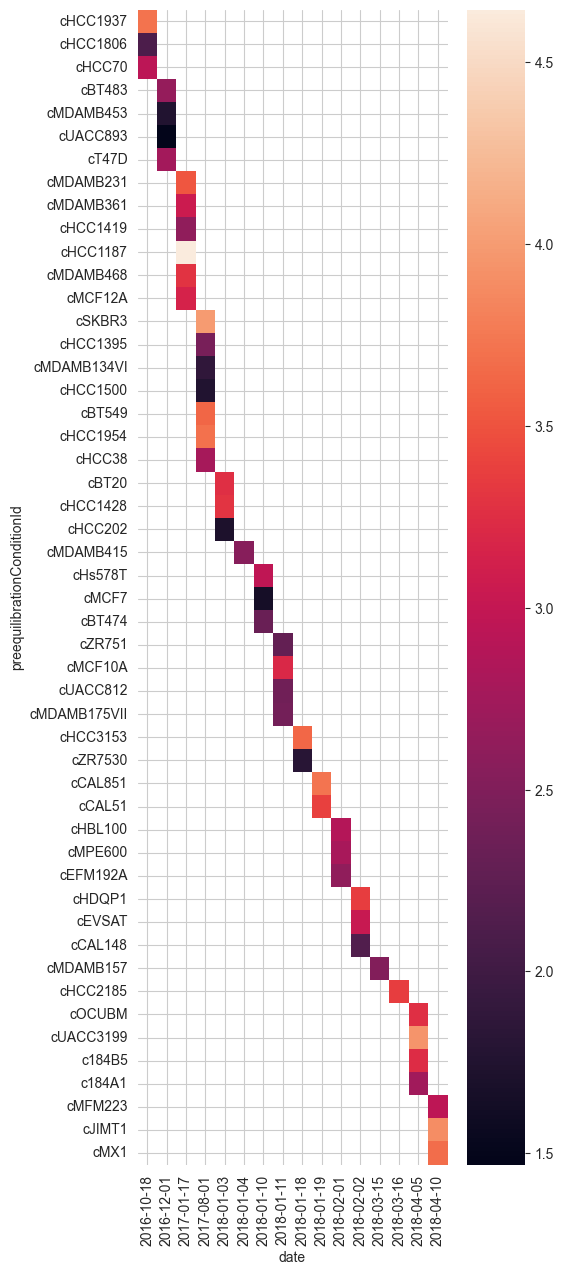

In [374]:
fig, ax = plt.subplots(figsize=(5, 15))
df_date =df[(df.observableId == 'p.p38') & (df.treatment == 'EGF') & (df.time == 13.0)].sort_values('date').pivot_table(
    index='date',
    columns='preequilibrationConditionId',
    values='measurement'
).T
sns.heatmap(df_date.loc[
    df[(df.observableId == 'p.p38') & (df.treatment == 'EGF') & (df.time == 13.0)].sort_values('date')['preequilibrationConditionId'].unique(),:
], ax=ax)


In [375]:
df[(df.observableId == 'p.p38') & (df.treatment == 'EGF') & (df.time == 13.0)].sort_values('min')

,observableId,preequilibrationConditionId,time,date,time_course,measurement,min,noiseParameters,simulationConditionId,measurementType,FEATURE_ID,treatment
82705,p.p38,cMDAMB453,13.0,2016-12-01,A,1.747634,0.203475,1.0,cMDAMB453__EGF,cytof,p.p38,EGF
81821,p.p38,cHCC1937,13.0,2016-10-18,A,3.711339,0.203475,1.0,cHCC1937__EGF,cytof,p.p38,EGF
81561,p.p38,cHCC1419,13.0,2017-01-17,A,2.620964,0.203475,1.0,cHCC1419__EGF,cytof,p.p38,EGF
82310,p.p38,cMCF12A,13.0,2017-01-17,A,3.151169,0.203475,1.0,cMCF12A__EGF,cytof,p.p38,EGF
81470,p.p38,cHCC1187,13.0,2017-01-17,A,4.645137,0.203475,1.0,cHCC1187__EGF,cytof,p.p38,EGF
82751,p.p38,cMDAMB468,13.0,2017-01-17,A,3.290638,0.203475,1.0,cMDAMB468__EGF,cytof,p.p38,EGF
82577,p.p38,cMDAMB231,13.0,2017-01-17,A,3.518996,0.203475,1.0,cMDAMB231__EGF,cytof,p.p38,EGF
82614,p.p38,cMDAMB361,13.0,2017-01-17,A,3.064733,0.203475,1.0,cMDAMB361__EGF,cytof,p.p38,EGF
81783,p.p38,cHCC1806,13.0,2016-10-18,A,2.103788,0.203475,1.0,cHCC1806__EGF,cytof,p.p38,EGF
83011,p.p38,cT47D,13.0,2016-12-01,A,2.753537,0.203475,1.0,cT47D__EGF,cytof,p.p38,EGF


In [568]:
df = pd.read_csv('./data/cytof.csv', index_col=0)
cell_lines = df['preequilibrationConditionId'].unique()
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
df = df[df['treatment'] == 'EGF']
df = df[df['observableId'].isin(['p.Akt.Ser473.', 'p.AKT.Thr308.', 'p.PDK1', 'p.GSK3b', 'p.p90RSK', 'p.SRC', 'p.ERK', 'p.MKK3.MKK6', 'p.MKK4', 'p.p38', 'p.JNK', 'p.HER2', 'p.PDPK1', 'p.MEK'])]
dfp = df.pivot_table(index=['treatment', 'time', 'observableId'], columns='preequilibrationConditionId', values='measurement')
dfp = dfp[dfp.isna().sum(axis=1) < 10]  # remove rows with too many NaNs
dfp

preequilibrationConditionId       c184A1  c184B5   cBT20  cBT474  cBT483  \
treatment time     observableId                                            
EGF       0.00000  p.AKT.Thr308. 2.30831 2.09542 2.65491 2.89199 2.04990   
                   p.Akt.Ser473. 2.10773 2.66140 4.15170 3.94594 3.29558   
                   p.ERK         2.61045 2.30394 3.80544 3.08993 2.94161   
                   p.GSK3b       1.86694 1.79600 4.02728 4.16809 2.88892   
                   p.JNK         1.67589 1.54165 1.66259 2.02534 1.35722   
...                                  ...     ...     ...     ...     ...   
          60.00000 p.MKK4        3.40930 3.77839 4.76308 3.41849 3.28637   
                   p.PDPK1       2.19705 1.94540 1.45122 2.04925 1.55083   
                   p.SRC         1.69061 2.06161 2.94370 2.42404 2.27461   
                   p.p38         1.76128 2.34052 3.03197 1.89330 2.56916   
                   p.p90RSK      2.56898 2.64598 4.75114 2.80844 2.99382   

preequilibrationConditionId       cBT549  cCAL148  cCAL51  cCAL851  cDU4475  \
treatment time     observableId                                               
EGF       0.00000  p.AKT.Thr308. 2.45795  2.39405 2.77131  2.12770  1.94136   
                   p.Akt.Ser473. 3.16024  4.28121 3.50573  3.07850  3.26934   
                   p.ERK         2.77473  1.96975 2.62547  3.29017  3.27670   
                   p.GSK3b       2.83498  3.55680 4.11513  3.07263  3.26609   
                   p.JNK         1.68094  1.56130 2.23367  1.79756  1.58131   
...                                  ...      ...     ...      ...      ...   
          60.00000 p.MKK4        3.83376  3.60957 4.60917  4.18099  3.42546   
                   p.PDPK1       1.04913  1.87689 2.42651  1.82789  1.91819   
                   p.SRC         2.27699  2.95527 2.79140  2.14162  2.99636   
                   p.p38         3.51108  2.09079 2.93742  3.60841  2.15917   
                   p.p90RSK      3.54960  3.19907 5.13542  4.41459  3.78307   

preequilibrationConditionId       ...  cMPE600    cMX1  cOCUBM  cSKBR3  \
treatment time     observableId   ...                                    
EGF       0.00000  p.AKT.Thr308.  ...  2.01452 2.29999 2.15491 2.62941   
                   p.Akt.Ser473.  ...  2.99204 3.94681 4.50083 3.21886   
                   p.ERK          ...  3.11704 2.70430 2.63847 3.03830   
                   p.GSK3b        ...  2.46399 3.67581 3.56826 2.77337   
                   p.JNK          ...  1.73269 1.53098 1.41156 1.74128   
...                               ...      ...     ...     ...     ...   
          60.00000 p.MKK4         ...  4.72131 2.80453 3.49089 4.00761   
                   p.PDPK1        ...  1.63367 2.58643 1.90353 1.05841   
                   p.SRC          ...  2.53562 2.01080 2.76492 1.93681   
                   p.p38          ...  2.66653 2.88801 2.57820 2.66348   
                   p.p90RSK       ...  3.10055 3.49692 3.35127 4.47935   

preequilibrationConditionId        cT47D  cUACC3199  cUACC812  cUACC893  \
treatment time     observableId                                           
EGF       0.00000  p.AKT.Thr308. 2.08622    2.15388   1.87126   2.30538   
                   p.Akt.Ser473. 2.72891    3.21481   2.78380   3.38971   
                   p.ERK         1.87211    4.21423   2.77440   2.53351   
                   p.GSK3b       3.38119    3.33089   2.41380   2.98208   
                   p.JNK         1.75855    1.74450   1.47858   1.26652   
...                                  ...        ...       ...       ...   
          60.00000 p.MKK4        3.34831    4.44943   3.55295   3.41806   
                   p.PDPK1       2.09904    2.35530   1.42945   1.72511   
                   p.SRC         2.50378    2.95883   2.15851   0.97555   
                   p.p38         2.00801    3.10258   2.04899   1.32706   
                   p.p90RSK      3.38135    5.07644   3.55963   2.15978   

preequilibrationConditionId       cZR751  cZ

In [562]:
df_px = pd.read_csv('./data/proteomics.csv', index_col=0)
df_px = df_px.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
).T.apply(zscore, nan_policy='omit').T
df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
).T.apply(zscore, nan_policy='omit').T

In [563]:
df_tx = df_tx[[c for c in df_tx.columns if c in dfp.columns]]

In [570]:
import tqdm
def row_correlation_matrix(A: pd.DataFrame, B: pd.DataFrame, method="pearson"):
    nA, nB = A.shape[0], B.shape[0]
    corr = np.zeros((nA, nB))
    for i in tqdm.trange(nA):
        for j in range(nB):
            corr[i, j] = A.iloc[i].corr(B.iloc[j], method=method)
    return pd.DataFrame(corr, index=A.index, columns=B.index)


In [571]:
corr_matrix = row_correlation_matrix(dfp, df_tx)

  0%|          | 0/120 [00:00<?, ?it/s][WARNING] /Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]

[WARNING] /Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]

100%|██████████| 120/120 [08:04<00:00,  4.04s/it]


In [572]:
corr_matrix.mean().abs().sort_values(ascending=False).index.tolist()

['CCDC78',
 'RNF41',
 'CDC14B',
 'KIAA1257',
 'PPP1R15B',
 'VCL',
 'GJA5',
 'FAHD1',
 'C18orf32',
 'CCDC87',
 'S100A4',
 'CERS6',
 'ANTXR1',
 'PLS3',
 'SPECC1',
 'GNA13',
 'RELB',
 'ABCC8',
 'HLA.DMB',
 'GBP1',
 'YWHAE',
 'AFAP1L1',
 'HABP4',
 'FPGT',
 'RPS12',
 'RARRES1',
 'ATP11B',
 'PNPLA7',
 'YBX3',
 'SORBS3',
 'CCDC102A',
 'PREPL',
 'NEDD9',
 'ANKRD50',
 'LRFN2',
 'MSRB3',
 'EME2',
 'FBXL16',
 'S100A5',
 'CHST3',
 'DNAJC14',
 'FSTL1',
 'UACA',
 'USP28',
 'SHC2',
 'SLC12A4',
 'SAMD4A',
 'CHD3',
 'CIRBP',
 'RIMBP3',
 'TGM2',
 'TIMP2',
 'SRPX2',
 'NT5E',
 'GJC1',
 'LMAN1L',
 'METRN',
 'PCBP2',
 'SLC18B1',
 'CCNT1',
 'RRAS2',
 'TBRG1',
 'CDH7',
 'THRSP',
 'SLC39A6',
 'SLC7A8',
 'SLC44A3',
 'PSD',
 'CALD1',
 'TSPAN2',
 'CHST8',
 'MMP25',
 'DPY19L3',
 'LCAT',
 'ANKS6',
 'HAGHL',
 'DGKD',
 'RPS6KA6',
 'SEPSECS',
 'IPO5',
 'TMBIM6',
 'EFNA3',
 'FSIP1',
 'CPVL',
 'SLC16A6',
 'ARID2',
 'KIF1C',
 'ZNF764',
 'CNPPD1',
 'ZYX',
 'SRI',
 'C17orf49',
 'LIF',
 'ZNF597',
 'COLGALT1',
 'GRM4',
 'MAM

In [573]:
corr_matrix[corr_matrix.mean().abs().sort_values(ascending=False).index.tolist()]

observableId                       CCDC78    RNF41  CDC14B  KIAA1257  \
treatment time     observableId                                        
EGF       0.00000  p.AKT.Thr308. -0.16369 -0.23421 0.09492  -0.21594   
                   p.Akt.Ser473. -0.24513 -0.28651 0.23378  -0.33557   
                   p.ERK         -0.44641 -0.42981 0.29457  -0.29786   
                   p.GSK3b       -0.18285 -0.17493 0.16345  -0.10947   
                   p.JNK         -0.40340 -0.40502 0.33842  -0.20051   
...                                   ...      ...     ...       ...   
          60.00000 p.MKK4        -0.55154 -0.55946 0.53098  -0.44399   
                   p.PDPK1       -0.19488 -0.10367 0.32878  -0.10968   
                   p.SRC         -0.09261 -0.26504 0.31917  -0.32110   
                   p.p38         -0.55070 -0.51217 0.39549  -0.53086   
                   p.p90RSK      -0.63184 -0.58995 0.45485  -0.51843   

observableId                      PPP1R15B     VCL     GJA5    FAHD1  \
treatment time     observableId                                        
EGF       0.00000  p.AKT.Thr308.  -0.34646 0.19626  0.28861 -0.09468   
                   p.Akt.Ser473.  -0.28870 0.24750  0.43708 -0.38741   
                   p.ERK          -0.21036 0.21134  0.44230 -0.33174   
                   p.GSK3b        -0.31737 0.15643  0.26030 -0.20674   
                   p.JNK          -0.31034 0.34335  0.16143 -0.24031   
...                                    ...     ...      ...      ...   
          60.00000 p.MKK4         -0.39789 0.41083  0.48753 -0.41688   
                   p.PDPK1        -0.21231 0.24557 -0.00558 -0.23088   
                   p.SRC          -0.16196 0.06844  0.18146 -0.37129   
                   p.p38          -0.43897 0.33096  0.50685 -0.50414   
                   p.p90RSK       -0.35304 0.41782  0.53703 -0.53135   

observableId                      C18orf32   CCDC87  ...  NR1H4  OR10A3  \
treatment time     observableId                      ...                  
EGF       0.00000  p.AKT.Thr308.   0.08925 -0.06017  ...    NaN     NaN   
                   p.Akt.Ser473.  -0.10077  0.01248  ...    NaN     NaN   
                   p.ERK          -0.21327 -0.22826  ...    NaN     NaN   
                   p.GSK3b         0.02900  0.09490  ...    NaN     NaN   
                   p.JNK          -0.19761 -0.41375  ...    NaN     NaN   
...                                    ...      ...  ...    ...     ...   
          60.00000 p.MKK4         -0.53143 -0.44839  ...    NaN     NaN   
                   p.PDPK1        -0.27053 -0.34767  ...    NaN     NaN   
                   p.SRC          -0.15537 -0.09300  ...    NaN     NaN   
                   p.p38          -0.37956 -0.42234  ...    NaN     NaN   
                   p.p90RSK       -0.40937 -0.44852  ...    NaN     NaN   

observableId                      OR10A6  PROKR1  PTPN7  REG3A  SLC18A3  \
treatment time     observableId                                           
EGF       0.00000  p.AKT.Thr308.     NaN     NaN    NaN    NaN      NaN   
                   p.Akt.Ser473.     NaN     NaN    NaN    NaN      NaN   
                   p.ERK             NaN     NaN    NaN    NaN      NaN   
                   p.GSK3b           NaN     NaN    NaN    NaN      NaN   
                   p.JNK             NaN     NaN    NaN    NaN      NaN   
...                                  ...     ...    ...    ...      ...   
          60.00000 p.MKK4            NaN     NaN    NaN    NaN      NaN   
                   p.PDPK1           NaN     NaN    NaN    NaN      NaN   
                   p.SRC             NaN     NaN    NaN    NaN      NaN   
                   p.p38             NaN     NaN    NaN    NaN      NaN   
                   p.p90RSK          NaN     NaN    NaN    NaN      NaN   

observableId                      SPACA3  TMEM150B  TRIML1  
treatment time     observableId                             
EGF       0.00000  p.AKT.Thr308.     NaN       NaN  

observableId
EGFR       0.16391
MAP2K2     0.15213
MAP2K3     0.10884
PBK        0.10525
ALDH1A3    0.09763
IKBKE      0.08097
RPS6KA1    0.08015
MAPK12     0.07937
RPS6KA2    0.07314
SRC        0.06385
MAP2K1     0.05603
MAP2K6     0.03059
MAPK14     0.03049
MAPK10     0.00427
SOS1      -0.00121
MAP2K4    -0.00724
MAPK9     -0.01464
MAPK11    -0.03234
MAPK1     -0.04351
MAPK8     -0.04633
MAPK13    -0.06322
GSK3B     -0.08244
GAB1      -0.10095
ERBB2     -0.13497
MAPK3     -0.14623
PDPK1     -0.21111
GRB2      -0.21190
dtype: float64